In [1]:
import os, sys
os.environ['CHIMERA_ENABLE_GPU'] = "True"
sys.path.append(os.getcwd()+'/../')
import jax.numpy as jnp
import matplotlib.pyplot as plt
from CHIMERA.population.mass.paired import random_features_density
from CHIMERA.population.mass import p_m1m2, p_m1, pdf_joint_and_marg

nn_config = dict(
    n_features=16,
    feature_scales=(1.0, 0.3, 0.1, 0.03),
    input_size=1,
)

model = random_features_density(**nn_config,
                       m_low=0.9245569825399548,  m_high=124.20678928592034,
                      bottomsmooth=0.08456654031744229, topsmooth=0.07731696292920931)
model


2026-09-15 14:31:31,990 - CHIMERA - INFO - Loading `CHIMERA`. GPU acceleration: True. USE x64: False. Safe-where guards: True. XLA FTZ: True.


/tmp/ipykernel_100295/1873295799.py:15: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  model = random_features_density(**nn_config,


random_features_density(
  m_low=0.9245569825399548,
  m_high=124.20678928592034,
  m_grid=f32[500],
  norm_2d=f32[],
  keys=[
    'm_low',
    'm_high',
    'beta',
    'bottomsmooth',
    'topsmooth',
    'input_size',
    'n_features',
    'feature_scales',
    'W_hidden',
    'b_hidden',
    'w_out'
  ],
  input_size=1,
  n_features=16,
  feature_scales=(1.0, 0.3, 0.1, 0.03),
  W_hidden=f32[16,1],
  b_hidden=f32[16],
  w_out=f32[16],
  beta=1.08,
  bottomsmooth=0.08456654031744229,
  topsmooth=0.07731696292920931,
  x_mean=weak_f32[],
  x_std=weak_f32[]
)

/home/mt/softwares/py_venv/gw-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/mt/softwares/CHIMERA/CHIMERA/population/mass/paired/base.py:77: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return self.__class__(**fiducials)
/home/mt/softwares/CHIMERA/CHIMERA/population/mass/paired/base.py:208: UserWarning: Explicitly requested dtype float64 requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  m1_arr = jnp.atleast_1d(jnp.asarray(m, dtype=jnp.float_))


/home/mt/softwares/CHIMERA/CHIMERA/population/mass/paired/base.py:77: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return self.__class__(**fiducials)
/home/mt/softwares/CHIMERA/CHIMERA/population/mass/paired/base.py:208: UserWarning: Explicitly requested dtype float64 requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  m1_arr = jnp.atleast_1d(jnp.asarray(m, dtype=jnp.float_))


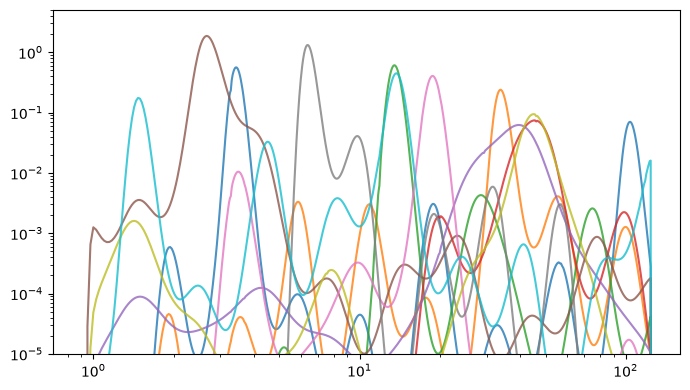

In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpyro.distributions as dist

def norm(loc, scale):
 return dist.Normal(loc=loc, scale=scale)

nn_config = dict(
    n_features=16,
    feature_scales=(1.0, 0.3, 0.1, 0.03),
    input_size=1,
)

# Only w_out is a free/sampled parameter for the random-features model --
# W_hidden/b_hidden are drawn once at construction and fixed forever, so
# there is nothing to put a prior on for them.
priors = {
    f"w_out{i}": norm(loc=0., scale=1.5) for i in range(nn_config['n_features'])
}
param_keys = list(priors.keys())

# ---------------------------------------------------------------------------
# A few random realizations, overlaid on the marginal
# ---------------------------------------------------------------------------

n_realizations = 10
master_key = jax.random.PRNGKey(1)
keys = jax.random.split(master_key, n_realizations)

input_size = model.input_size
n_features = model.n_features

fig, ax = plt.subplots(1, 1, figsize=(7, 4))

m1 = jnp.linspace(0.9,125,5000)

for i, key in enumerate(keys):
  subkeys = jax.random.split(key, len(param_keys))
  w_out = jnp.array([priors[k].sample(subkeys[j]) for j, k in enumerate(param_keys)])
  model_rand = model.update(w_out=w_out)

  pdf = p_m1(model_rand, m1)
  ax.plot(m1, pdf, alpha=0.8, label=f"draw {i}")
  ax.set_xscale('log')
  ax.set_yscale('log')
  ax.set_ylim(1e-5,5)  

fig.tight_layout()
plt.show()


In [3]:
m1 = jnp.linspace(0.5,150,5000)
m1g = jnp.array([m1 for _ in range(300)]).T
m2g = m1g*0.8

@jax.jit
def jitted_p_m1m2(model, m1, m2):
    return p_m1m2(model, m1, m2)

jitted_p_m1m2(model_rand, m1g, m2g)

%timeit -n 10 jitted_p_m1m2(model_rand, m1g, m2g).block_until_ready()

8.7 ms ± 202 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


2.91 ms ± 81.3 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


(1e-05, 3)

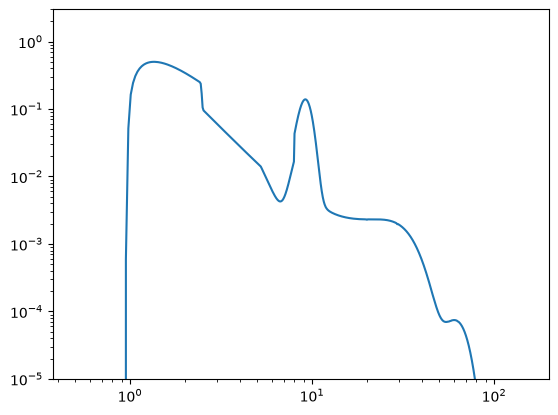

In [4]:
from CHIMERA.population.mass.paired import bpl_dip_three_peaks

model_2 = bpl_dip_three_peaks()
jitted_p_m1m2(model_2, m1g, m2g)
%timeit -n 10 jitted_p_m1m2(model_2, m1g, m2g).block_until_ready()

plt.plot(m1, p_m1(model_2, m1))
plt.yscale('log')
plt.xscale('log')
plt.ylim(1e-5,3)  

/tmp/ipykernel_100295/505637257.py:96: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  base_model = random_features_density(


  step     0  MSE(log p) = 1.877e+01


  step  5000  MSE(log p) = 1.098e-01


  step 10000  MSE(log p) = 8.176e-02


  step 15000  MSE(log p) = 7.932e-02


...

  step 80000  MSE(log p) = 7.817e-02


  step 85000  MSE(log p) = 7.811e-02


  step 90000  MSE(log p) = 7.806e-02


  step 95000  MSE(log p) = 7.801e-02


  step 100000  MSE(log p) = 7.798e-02  (final)


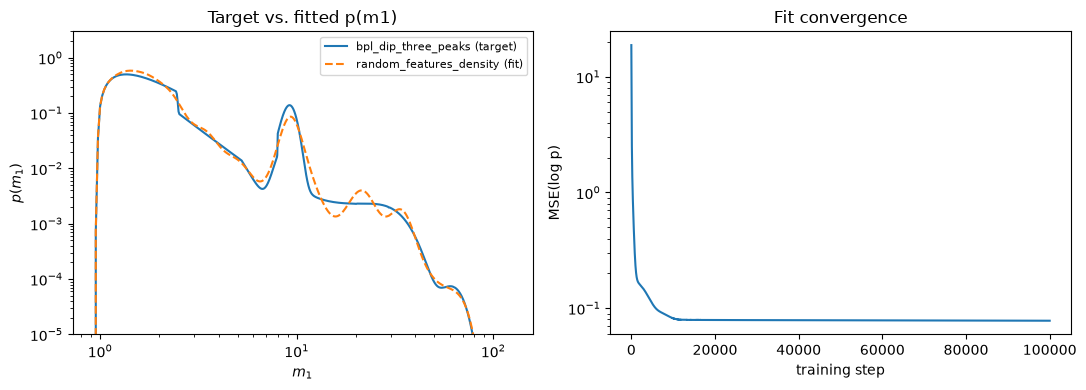

In [5]:
import jax
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt

def fit_to_target_p_m1(target_model, base_model, n_grid=1000,
                        n_steps=5000, lr=3e-3, eps=1e-12, verbose=True):
  """Fit `base_model.w_out` so p_m1(base_model, .) matches
  p_m1(target_model, .), by MSE regression in log-space.

  NOTE: this cell is a diagnostic/expressiveness check only -- fitting
  w_out against a target *parametric* shape like this is not how the
  random-features model is meant to be used for actual population
  inference. w_out is meant to be inferred directly inside the
  hierarchical Bayesian fit (see priors["w_out"] in cell 1 above), with
  no pretraining step and no dependence on an assumed target shape. This
  cell instead answers a narrower question: how well can a K-feature
  random basis approximate a *given* shape at all, as a sanity check on
  `n_features` / `feature_scales` before using the model for inference.

  Log-space (rather than linear) is used because p(m1) spans several
  orders of magnitude (dip + peaks); a linear MSE would be dominated by
  the tallest peak and effectively ignore the dip/tails, whereas
  log-space matches what you actually judge by eye on the usual log-y
  plot.

  Parameters
  ----------
  target_model : any CHIMERA paired mass model instance (e.g.
      `bpl_dip_three_peaks()`) whose p_m1 curve to reproduce.
  base_model : a `random_features_density` instance providing the fixed
      random basis (W_hidden/b_hidden) and mass range to fit into, e.g.
      `random_features_density(n_features=16, m_low=..., m_high=...)`.
      Its current w_out is just the optimizer's starting point.
  n_grid : number of log-spaced m1 points used for the regression.
  lr : peak learning rate. Adam uses a cosine decay from `lr` down to
      `0.01 * lr` over `n_steps`, rather than a fixed rate -- helps the
      loss actually settle near the end instead of bouncing around the
      minimum at full step size.
  eps : floor added before taking log, to avoid log(0) near the hard
      mass-range cutoff.

  Returns
  -------
  fitted_model : base_model with the fitted w_out plugged in.
  losses : jnp.ndarray, per-step training loss.
  """

  m_low, m_high = base_model.m_low, base_model.m_high
  m_grid = jnp.logspace(
    jnp.log10(m_low), jnp.log10(m_high), n_grid,
  )

  target = p_m1(target_model, m_grid)
  log_target = jnp.log(target + eps)

  params0 = base_model.w_out

  def loss_fn(w_out):
    model = base_model.update(w_out=w_out)
    pred = p_m1(model, m_grid)
    log_pred = jnp.log(pred + eps)
    return jnp.mean((log_pred - log_target) ** 2)

  lr_schedule = optax.cosine_decay_schedule(
    init_value=lr, decay_steps=n_steps, alpha=0.01,
  )
  optimizer = optax.adam(lr_schedule)
  opt_state = optimizer.init(params0)


  @jax.jit
  def step(params, opt_state):
    loss, grads = jax.value_and_grad(loss_fn)(params)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

  params = params0
  losses = []
  for i in range(n_steps):
    params, opt_state, loss = step(params, opt_state)
    losses.append(loss)
    if verbose and i % 5_000 == 0:
      print(f"  step {i:5d}  MSE(log p) = {loss:.3e}")

  fitted_model = base_model.update(w_out=params)
  if verbose:
    print(f"  step {n_steps:5d}  MSE(log p) = {losses[-1]:.3e}  (final)")

  return fitted_model, jnp.array(losses)


model_target = bpl_dip_three_peaks()

base_model = random_features_density(
    n_features=64, feature_scales=(1.0, 0.3, 0.1, 0.03),
    bottomsmooth=model_target.bottomsmooth, topsmooth=model_target.topsmooth,
    m_low=model_target.m_low, m_high=model_target.m_high,
)

fitted_model, losses = fit_to_target_p_m1(model_target, base_model, n_steps=100_000)

m1 = jnp.linspace(model_target.m_low, model_target.m_high, 5000)
pdf_target = p_m1(model_target, m1)
pdf_fit = p_m1(fitted_model, m1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(m1, pdf_target, label="bpl_dip_three_peaks (target)")
axes[0].plot(m1, pdf_fit, "--", label="random_features_density (fit)")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_ylim(1e-5, 3)
axes[0].set(xlabel="$m_1$", ylabel="$p(m_1)$", title="Target vs. fitted p(m1)")
axes[0].legend(fontsize=8)

axes[1].plot(losses)
axes[1].set_yscale("log")
axes[1].set(xlabel="training step", ylabel="MSE(log p)", title="Fit convergence")

fig.tight_layout()
plt.show()


In [6]:
# final loss -- see printed output of the cell above once (re-)run


In [7]:
print("std(w_out):", jnp.std(fitted_model.w_out))
fitted_model.w_out


std(w_out): 2.4876041


Array([-0.5518015 ,  3.6511    ,  0.60792375,  0.4643237 , -0.63980806,
       -0.44126603, -0.5364663 , -0.70608675, -0.5414873 ,  6.124788  ,
        0.6015847 , -0.6257583 , -0.5124133 ,  0.55371284,  0.62753254,
       -0.43522108,  0.1601272 , -5.708269  , -0.03744524,  0.22265571,
       -0.34655538,  0.49664596, -0.5082708 ,  0.67621785, -0.02187956,
        0.65868026, -2.5718815 , -2.708285  ,  0.16855447,  0.6469149 ,
        0.67154396,  0.7692993 , -1.5903898 , -1.7963281 , -0.9763678 ,
       -0.384467  , -1.3372134 , -2.63125   , -1.1425877 ,  2.0589933 ,
        5.926204  , -2.2557247 , -0.79870635,  1.1892827 , -1.395173  ,
       -0.38673756,  3.2062745 , -0.5280196 , -2.977645  ,  0.03941926,
       -1.7530133 ,  8.61078   , -3.6663575 , -0.01088814, -0.03097847,
       -8.119297  ,  6.5325646 ,  1.8036736 ,  0.6471524 ,  1.5016212 ,
       -0.997385  , -0.13701959,  0.09231956,  0.1151759 ], dtype=float32)

In [8]:
print("initial w_out (all zeros):", base_model.w_out)
print("fitted w_out:          ", fitted_model.w_out)


initial w_out (all zeros): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
fitted w_out:           [-0.5518015   3.6511      0.60792375  0.4643237  -0.63980806 -0.44126603
 -0.5364663  -0.70608675 -0.5414873   6.124788    0.6015847  -0.6257583
 -0.5124133   0.55371284  0.62753254 -0.43522108  0.1601272  -5.708269
 -0.03744524  0.22265571 -0.34655538  0.49664596 -0.5082708   0.67621785
 -0.02187956  0.65868026 -2.5718815  -2.708285    0.16855447  0.6469149
  0.67154396  0.7692993  -1.5903898  -1.7963281  -0.9763678  -0.384467
 -1.3372134  -2.63125    -1.1425877   2.0589933   5.926204   -2.2557247
 -0.79870635  1.1892827  -1.395173   -0.38673756  3.2062745  -0.5280196
 -2.977645    0.03941926 -1.7530133   8.61078    -3.6663575  -0.01088814
 -0.03097847 -8.119297    6.5325646   1.8036736   0.6471524   1.5016212
 -0.997385   -0.13701959  0.0923

In [9]:
fitted_model.beta


1.08

In [10]:
model_target

bpl_dip_three_peaks(
  m_low=0.9245569825399548,
  m_high=124.20678928592034,
  m_grid=f32[500],
  norm_2d=f32[],
  keys=[
    'm_low',
    'm_high',
    'alpha_1',
    'alpha_2',
    'beta_bottom',
    'beta_top',
    'mu_g1',
    'sigma_g1',
    'mu_g2',
    'sigma_g2',
    'mu_g3',
    'sigma_g3',
    'lambda_g',
    'lambda_1',
    'lambda_2',
    'bottomsmooth',
    'topsmooth',
    'leftdip',
    'rightdip',
    'leftdipsmooth',
    'rightdipsmooth',
    'deep'
  ],
  alpha_1=1.7723937807650858,
  alpha_2=5.063826317550281,
  beta_bottom=1.5835680997888992,
  beta_top=2.4359528976425393,
  mu_g1=8.903700220355121,
  sigma_g1=0.8391676748455468,
  mu_g2=24.556312970528175,
  sigma_g2=10.002284990279694,
  mu_g3=62.73443845058334,
  sigma_g3=8.683579188378397,
  lambda_g=0.3274896479007529,
  lambda_1=0.6348482960571541,
  lambda_2=0.9357685300341941,
  bottomsmooth=0.08456654031744229,
  topsmooth=0.07731696292920931,
  leftdip=2.416688462245518,
  rightdip=8.017044339987327,
  le